In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.cm as cm
cmap = cm.get_cmap('magma')

size=15
params = {'legend.fontsize': 'large',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size,
          'ytick.labelsize': size,
          'axes.titlepad': 5,
          'lines.linewidth': 2,
          'figure.dpi': 100}
plt.rcParams.update(params)


data_dir = 'raw_data_kymos/'

from SVD_analysis.src.data_settings import sample_names_newreg, sample_dt, sample_somite_stage, sample_colors, sample_temperatures

/var/folders/yn/r99j3qy962lg5cwmzc1dpqg40000gn/T/ipykernel_14323/3353367014.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('magma')


In [3]:
sample_names = sample_names_newreg

del sample_names['new_registration_27C']

tuples = []
for exp in sample_names:
    for date in sample_names[exp]:
        for loc in sample_names[exp][date]:
            tuples.append((exp, date, loc))

index = pd.MultiIndex.from_tuples(tuples, names=["Experiment", "Date", "P"])

df = pd.DataFrame(index=index, columns=['ss', 'dt', 'color',
                                       ])
df = df.sort_index()

# print(df_6h.index)
print(sample_dt)
for exp in df.index.levels[0]:
    df.loc[exp, 'Temp'] = sample_temperatures[exp]
    df.loc[exp, 'dt'] = sample_dt[exp]
    df.loc[exp, 'ss'] = sample_somite_stage[exp]
    df.loc[exp, 'color'] = sample_colors[exp]

print(df.head(3))
print(df.index)

{'TE_22C_14ss': 10.0, 'TE_22C_15ss': 10.0, 'TE_27C_14ss': 10.0, 'TE_27C_17ss': 10.0, 'TE_32C_15ss': 10.0, 'TE_32C_14ss_5dt': 5.0, 'TE_27C_14ss_het': 10.0, 'TE_27C_14ss_wt': 10.0, 'TE_21-27C12h_15ss': 10.0, 'TE_21-27C_13ss': 10.0, 'TE_21-27C_14ss': 10.0, 'TE_21-27C_14ss_wt': 10.0, '221128_her7Het': 10.0, '221129_her7Het': 10.0, '230501_5minDelT': 5.0, '221128': 10.0, '221129': 10.0, 'new_registration_22C': 10.0, 'new_registration_27C': 10.0, 'new_reg_27C_betaCatenin': 10.0, 'data_longExperiments/27C': 10.0, 'hilbert/6h': 10.0, 'hilbert/12h': 10.0, 'hilbert/24h': 10.0}
                                    ss    dt       color  Temp
Experiment              Date     P                            
new_reg_27C_betaCatenin 20210209 1  15  10.0  lightgreen  27.0
                                 2  15  10.0  lightgreen  27.0
                        20210516 1  15  10.0  lightgreen  27.0
MultiIndex([('new_reg_27C_betaCatenin', '20210209', 1),
            ('new_reg_27C_betaCatenin', '20210209', 2),

In [4]:
def v_tb_exp(T):
    return 1.38*0.0816*(1  + 0.0439*(T-27))

def T_from_v_tb(v_tb):
    return (v_tb/0.0816 - 1.)/0.0439

def v_f_exp(T):
    return 1.38*0.1464*(1 + 0.075*(T-27))

def v_f_from_v_tb(v_tb):
    return 0.1464*(1 + 0.075*T_from_v_tb(v_tb))

def omega_exp(T):
    return 0.0781*(1. + 0.076*(T-27))

def moving_average(array, kernel_size):
    array_padded = np.pad(array, (kernel_size//2, kernel_size-1-kernel_size//2), mode='edge')
    array_smooth = np.convolve(array_padded, np.ones((kernel_size,))/kernel_size, mode='valid')
    return array_smooth

viridis_group = plt.cm.get_cmap('viridis', 4)
group_colors = viridis_group(np.linspace(0, 1, 4))

color_vf = 'darkorange'
color_vtb = '#5dade2'
color_freq = group_colors[0]
# color_freq = group_colors[0]

/var/folders/yn/r99j3qy962lg5cwmzc1dpqg40000gn/T/ipykernel_14323/1395859417.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis_group = plt.cm.get_cmap('viridis', 4)


In [5]:
def edge_filename(exp, date, sample, edge=2):
    # edge=1  - front,  edge=2  - tailbud
    filename = data_dir + exp + '/edges_coordinates/'+'fromDiscreteMaxDerivative/'+ date +'_P'+str(sample)+ '_edges_' + str(edge) + '.csv'
    return filename


In [6]:
post = np.loadtxt(edge_filename(*df.index[0], edge=2), delimiter=',')
print(post)

[[  1.   433.32]
 [  2.   433.32]
 [  3.   438.15]
 [  4.   442.29]
 [  5.   445.74]
 [  6.   454.02]
 [  7.   460.23]
 [  8.   459.54]
 [  9.   458.85]
 [ 10.   456.78]
 [ 11.   456.78]
 [ 12.   456.78]
 [ 13.   458.16]
 [ 14.   459.54]
 [ 15.   467.82]
 [ 16.   470.58]
 [ 17.   475.41]
 [ 18.   478.17]
 [ 19.   478.86]
 [ 20.   484.38]
 [ 21.   488.52]
 [ 22.   492.66]
 [ 23.   493.35]
 [ 24.   494.73]
 [ 25.   497.49]
 [ 26.   500.25]
 [ 27.   502.32]
 [ 28.   503.01]
 [ 29.   505.77]
 [ 30.   507.84]
 [ 31.   509.91]
 [ 32.   514.05]
 [ 33.   514.74]
 [ 34.   519.57]
 [ 35.   520.95]
 [ 36.   520.95]
 [ 37.   521.64]
 [ 38.   523.71]
 [ 39.   529.23]
 [ 40.   535.44]
 [ 41.   537.51]
 [ 42.   538.89]
 [ 43.   540.27]
 [ 44.   545.1 ]
 [ 45.   547.17]
 [ 46.   547.17]
 [ 47.   547.86]
 [ 48.   547.86]
 [ 49.   548.55]
 [ 50.   548.55]
 [ 51.   550.62]
 [ 52.   554.07]
 [ 53.   555.45]
 [ 54.   558.21]
 [ 55.   560.28]
 [ 56.   560.97]
 [ 57.   565.8 ]
 [ 58.   566.49]
 [ 59.   570.6

In [7]:
def fit_velocities(edge, dx=1., dt=1., plot=False):
    # tt = np.arange(len(edge)) * dt
    tt = edge[:, 0] * dt

    #     fit_f, pcov_f = curve_fit(linear, tt, psm_edges[0][0], p0=(0., 0.))
    fit_tb, pcov_tb = np.polyfit(tt, edge[:, 1], 1, cov=True)
    perr_tb = np.sqrt(np.diag(pcov_tb))

    v_tb = fit_tb[0] * dx
    v_tb_err = perr_tb[0] * dx

    x0_tb = fit_tb[1] * dx

    if plot:
        # fig, ax = plt.subplots(1, 1, figsize=(3, 3))
        # ax.plot(tt/60, edge[:, 1]-x0_tb, '-', c='steelblue')
        plt.plot(tt/60, edge[:, 1]*dx -x0_tb, '-', c=sample_colors[index[0]])
        
        # ax.set_title('Posterior edge')
        # plt.plot(tt/60, (fit_tb[0] * tt + fit_tb[1])-x0_tb, c='indianred')
        plt.plot(tt/60, (fit_tb[0] * tt + fit_tb[1])*dx -x0_tb, c=sample_colors[index[0]], alpha=0.5)
        
        plt.xlabel('Time, h')
        plt.ylabel('Tailbud coordinate, um')
        plt.xticks(np.arange(0, np.max(tt)/60, 4))
        # plt.show()
        df.loc[index, 'v_tb'] = v_tb
        df.loc[index, 'v_tb err'] = v_tb_err
    print(v_tb)
    return v_tb, v_tb_err

('new_reg_27C_betaCatenin', '20210209', 1)
0.19903971778283744
('new_reg_27C_betaCatenin', '20210209', 2)
0.17841110835606283
('new_reg_27C_betaCatenin', '20210516', 1)
0.19159798931542082
('new_reg_27C_betaCatenin', '20210516', 2)
0.17207865563645391
('new_registration_22C', '20200817', 2)
0.11483168316831646
('new_registration_22C', '20200817', 3)
0.09782442276824284
('new_registration_22C', '20210301', 1)
0.17787157287157343
('new_registration_22C', '20210301', 5)
0.1750483048304822
('new_registration_22C', '20210301', 6)
0.1767756213823627
('new_registration_22C', '20210301', 7)
0.16217804667242838


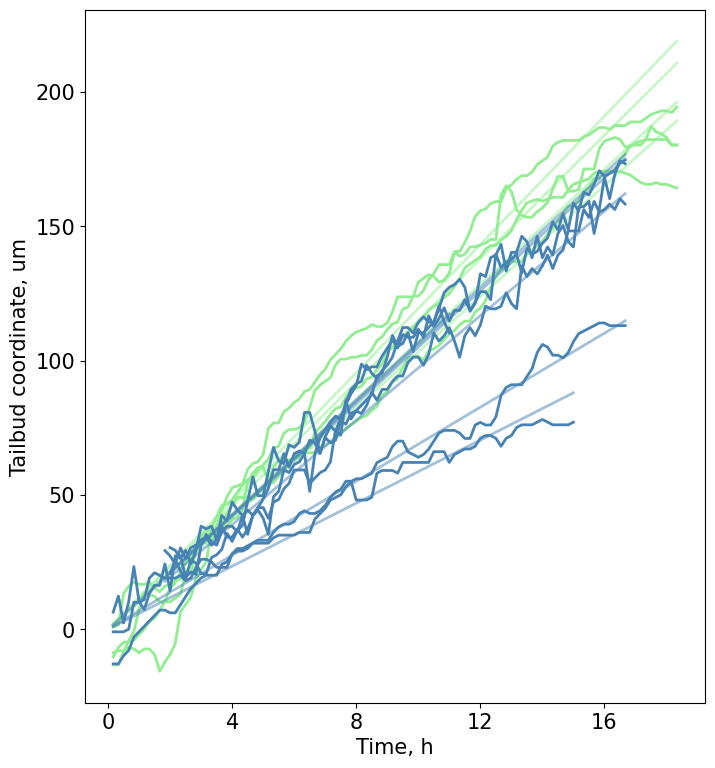

In [8]:
plt.figure(figsize=(8,9))
for index in df.index:
    print(index)
    edge_coords = np.loadtxt(edge_filename(*index, edge=2), delimiter=',')
    v_tb, v_tb_err = fit_velocities(edge_coords, dx=1., dt=sample_dt[index[0]], plot=True)

In [9]:
print(df)

                                    ss    dt       color  Temp      v_tb  \
Experiment              Date     P                                         
new_reg_27C_betaCatenin 20210209 1  15  10.0  lightgreen  27.0  0.199040   
                                 2  15  10.0  lightgreen  27.0  0.178411   
                        20210516 1  15  10.0  lightgreen  27.0  0.191598   
                                 2  15  10.0  lightgreen  27.0  0.172079   
new_registration_22C    20200817 2  14  10.0   steelblue  22.0  0.114832   
                                 3  14  10.0   steelblue  22.0  0.097824   
                        20210301 1  14  10.0   steelblue  22.0  0.177872   
                                 5  14  10.0   steelblue  22.0  0.175048   
                                 6  14  10.0   steelblue  22.0  0.176776   
                                 7  14  10.0   steelblue  22.0  0.162178   

                                    v_tb err  
Experiment              Date     P      

0.1779872736867607 0.04090949111871441
0.04090949111871441


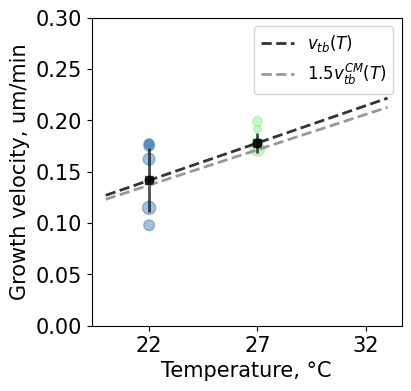

In [10]:
plt.figure(figsize=(4,4))

v_27 = np.mean(df['v_tb'][df['Temp']==27])

Temps = df['Temp']
vtb = df['v_tb']
errors = df['v_tb err']
s = 1/errors
s *= 60./np.mean(s)
plt.scatter(Temps, vtb, c=df['color'], s=s, alpha=0.5)



linear_fit, pcov = np.polyfit(Temps-27, vtb, 1, w=1/errors, cov=True)
k = linear_fit[0]/linear_fit[1]
perr = np.sqrt(np.diag(pcov))
k_err = np.sqrt( (perr[0]/linear_fit[1])**2 + (k/linear_fit[1]*perr[1])**2)


for iT, Temp in enumerate((22., 27.,)):
    results = np.asarray(df.loc[df['Temp'] == Temp, 'v_tb']).astype('float')
    errors = np.asarray(df.loc[df['Temp'] == Temp, 'v_tb err']).astype('float')
    avg = np.average(results, weights=1./errors**2)
    std = np.sqrt(np.average((results - avg)**2, weights=1./errors**2))
    plt.scatter(Temp, avg, c='k', marker='s', alpha=0.6)
    plt.errorbar(Temp, avg, yerr=std, fmt="o", c='k', alpha=0.7)


plt.plot(np.linspace(20, 33, 11), linear_fit[0]*(np.linspace(20, 33, 11)-27)+linear_fit[1], '--', c = 'k', alpha=0.8, label='$v_{tb} (T)$')
print(linear_fit[1], linear_fit[0]/linear_fit[1])

v_tb_exp(27)
# plt.plot((21., 33.), v_tb_exp(np.array((22., 33.))), '--', color='grey', alpha=0.7, label='Old reg')
# plt.plot((21., 33.), 1.55*1.38*v_tb_exp(np.array((22., 33.))), '--', color='grey', alpha=0.7, label='Old reg scaled')

# Old function
# plt.plot((21., 33.), 1.5 * 0.116*(1 + 0.0512*(np.array((22., 33.)) -27)), '--', color='grey', alpha=0.7, label='$1.5 v_{tb}^{CM} (T)$')
# Fig 5 function
plt.plot(np.linspace(20, 33, 11), 0.1714 *(1 + 0.040239 *(np.linspace(20, 33, 11) -27)), '--', color='grey', alpha=0.8, label='$1.5 v_{tb}^{CM} (T)$')


# plt.plot((21., 33.), 0.12 + v_tb_exp(np.array((22., 33.))), '--', color='grey', alpha=0.7, label='Old reg additive')

print(linear_fit[0]/linear_fit[1])
# plt.xlim((21, 33))
plt.ylim((0., 0.3))
plt.xticks((22, 27, 32))
plt.legend()
plt.xlabel('Temperature, °C')
plt.ylabel('Growth velocity, um/min')
plt.show()

In [11]:
print(linear_fit[1]/v_tb_exp(27))

1.5805917313757523


In [ ]:
2*np.pi/0.05